### Questão 5

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

import pickle
import os

2025-09-01 18:44:07.054071: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-01 18:44:07.109393: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-01 18:44:08.614391: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
vocab_size = 10000
maxlen = 256
embedding_dim = 128
gru_units = 128
buffer_size = 10000
batch_size = 64

In [4]:
(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.imdb.load_data(
    num_words=vocab_size
)

train_data = tf.keras.preprocessing.sequence.pad_sequences(
    train_data, maxlen=maxlen, padding="post", truncating="post"
)
test_data = tf.keras.preprocessing.sequence.pad_sequences(
    test_data, maxlen=maxlen, padding="post", truncating="post"
)

train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels))

train_dataset = (
    train_dataset.shuffle(buffer_size)
    .batch(batch_size)
    .prefetch(tf.data.experimental.AUTOTUNE)
)
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)

W0000 00:00:1756763054.562812   76869 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=maxlen),
        tf.keras.layers.GRU(gru_units),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer="adam",
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

model.summary()

/home/thiag/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
epochs = 5
history = model.fit(train_dataset, epochs=epochs, validation_data=test_dataset)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 97s 244ms/step - accuracy: 0.5166 - loss: 0.6944 - val_accuracy: 0.5217 - val_loss: 0.6887
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 119s 305ms/step - accuracy: 0.5722 - loss: 0.6727 - val_accuracy: 0.5110 - val_loss: 0.7072
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 122s 313ms/step - accuracy: 0.6834 - loss: 0.5839 - val_accuracy: 0.7752 - val_loss: 0.4907
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 120s 307ms/step - accuracy: 0.7670 - loss: 0.5096 - val_accuracy: 0.7660 - val_loss: 0.5017
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 116s 298ms/step - accuracy: 0.8452 - loss: 0.3600 - val_accuracy: 0.8166 - val_loss: 0.4144


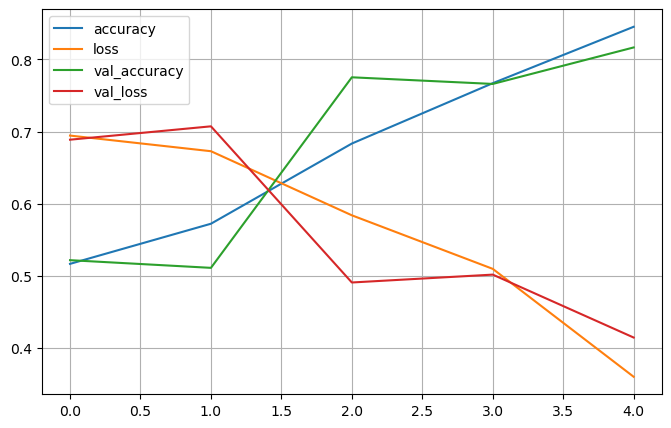

In [7]:
# Training Metrics

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

In [11]:
loss, accuracy = model.evaluate(test_dataset)
print(f"Acurácia do modelo no conjunto de teste: {accuracy*100:.2f}%")

model.save("sentimento_modelo.h5")

391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.8166 - loss: 0.4144


Acurácia do modelo no conjunto de teste: 81.66%


In [9]:
# Obter o índice de palavras para a tokenização

word_index = tf.keras.datasets.imdb.get_word_index()
word_index = {k: (v + 3) for k, v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2
word_index["<UNUSED>"] = 3
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])


def decode_review(text):
    return " ".join([reverse_word_index.get(i, "?") for i in text])


# Salvar o tokenizador (mapa de palavras)
with open("imdb_word_index.pkl", "wb") as f:
    pickle.dump(word_index, f)

In [10]:
def predict_sentiment(text, model, word_index, maxlen=maxlen):
    # Pré-processar o texto
    words = text.lower().split()
    tokens = [word_index.get(word, word_index["<UNK>"]) for word in words]
    padded_tokens = tf.keras.preprocessing.sequence.pad_sequences(
        [tokens], maxlen=maxlen, padding="post", truncating="post"
    )

    # Fazer a previsão
    prediction = model.predict(padded_tokens)[0][0]

    # Mapear a previsão para sentimento
    if prediction >= 0.5:
        return f"Positivo ({prediction*100:.2f}%)"
    else:
        return f"Negativo ({prediction*100:.2f}%)"


# Carregar o modelo e o tokenizador para um novo uso
print("\n--- Testando o modelo com uma nova frase ---")
loaded_model = tf.keras.models.load_model("sentimento_modelo.h5")
with open("imdb_word_index.pkl", "rb") as f:
    loaded_word_index = pickle.load(f)

# Frases de exemplo
review_positive = "This movie was absolutely fantastic! The acting was superb and the story was very engaging."
review_negative = "The movie was a complete disaster. The plot was confusing and the acting was terrible."

print(f"Frase: '{review_positive}'")
print(
    f"Sentimento previsto: {predict_sentiment(review_positive, loaded_model, loaded_word_index)}"
)

print(f"\nFrase: '{review_negative}'")
print(
    f"Sentimento previsto: {predict_sentiment(review_negative, loaded_model, loaded_word_index)}"
)


--- Testando o modelo com uma nova frase ---
Frase: 'This movie was absolutely fantastic! The acting was superb and the story was very engaging.'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
Sentimento previsto: Positivo (93.53%)

Frase: 'The movie was a complete disaster. The plot was confusing and the acting was terrible.'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Sentimento previsto: Negativo (25.59%)
